In [63]:
import pandas as pd
import  numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import datetime as dt
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from    sklearn import tree 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
df= pd.read_csv("data/data.csv")
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,"0,85",12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,"2,1",12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,"4,15",12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,"4,15",12680.0,France


## EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  str    
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 68.3 MB


In [4]:
df.shape

(541909, 8)

In [5]:
df.head()
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:

df.dtypes


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice          str
CustomerID     float64
Country            str
dtype: object

In [7]:
df.describe()

,Quantity,CustomerID
count,541909.000000,406829.000000
mean,9.552250,15287.690570
std,218.081158,1713.600303
min,-80995.000000,12346.000000
25%,1.000000,13953.000000
50%,3.000000,15152.000000
75%,10.000000,16791.000000
max,80995.000000,18287.000000


### data preparing

In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### convert InvocieNo to float

### traiter  les donness manquantes

In [9]:
df.dropna(subset=['CustomerID'],inplace=True)
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Analyse CostumerID 

In [10]:
df['CustomerID'].head()
df['CustomerID'].dtype

df['CustomerID'].isna().sum()

df['CustomerID'].nunique()


4372

In [11]:
df['CustomerID'].value_counts().describe()     

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: count, dtype: float64

In [12]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

C:\Users\Youcode\AppData\Local\Temp\ipykernel_4424\2208571527.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice                 str
CustomerID            float64
Country                   str
dtype: object

## traiter les donnees  

In [13]:
df_uniq=df['CustomerID'].isna().sum()
print(df_uniq)
df
df['UnitPrice']=df['UnitPrice'].str.replace(',','.').astype(float)

0


<Axes: xlabel='Country'>

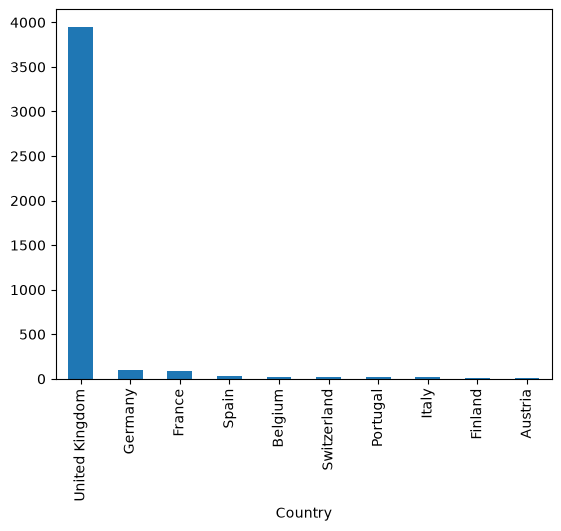

In [14]:
filtered_data=df[['Country','CustomerID']].drop_duplicates()


filtered_data.Country.value_counts()[:10].plot(kind='bar')

### RFM

In [15]:
df_rfm = df.copy()
df_rfm = df_rfm[df_rfm['Quantity'] > 0]
df_rfm = df_rfm[df_rfm['UnitPrice'] > 0]

print(df_rfm.shape)
df_rfm.head()

(397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Frequency

In [16]:
freq = df_rfm.groupby('CustomerID')['InvoiceNo'].nunique().rename('Frequence')
freq.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: Frequence, dtype: int64

### Recency

In [17]:

Now = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

last_sales = df_rfm.groupby('CustomerID')['InvoiceDate'].max()

recence = (Now - last_sales).dt.days.rename('Recence')
recence.head()

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: Recence, dtype: int64

### Monetary

In [18]:
df_rfm['Total_Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']

montant = df_rfm.groupby('CustomerID')['Total_Price'].sum().rename('Montant')
montant.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Montant, dtype: float64

In [19]:
rfm = pd.concat([recence, freq, montant], axis=1).reset_index()
rfm.columns = ['CustomerID', 'Recence', 'Frequence', 'Montant']

print(rfm.shape)
print(rfm.isna().sum())
rfm.head()

(4338, 4)
CustomerID    0
Recence       0
Frequence     0
Montant       0
dtype: int64


,CustomerID,Recence,Frequence,Montant
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### des indicateurs RFM
Recence:Nombre de jours depuis le dernier achat du client

frequence : Nombre de commandes distinctes passees par le client

Montery : Somme totale depensee par le client

#### Préparation des variables pour le clustering

In [20]:

rfm[['Recence', 'Frequence', 'Montant']].describe()

,Recence,Frequence,Montant
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


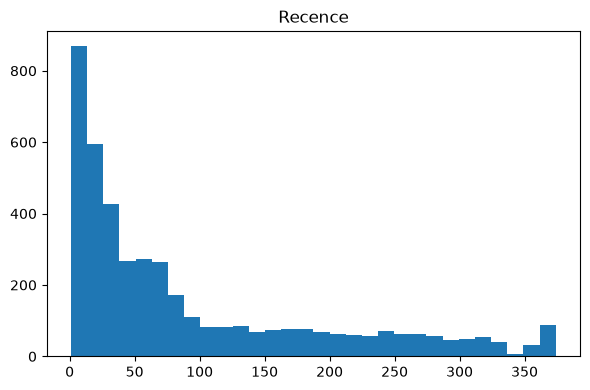

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Recence'], bins=30)
ax.set_title('Recence')
plt.tight_layout()
plt.show()

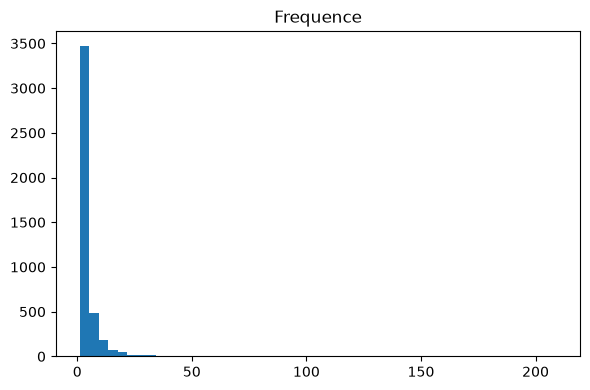

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

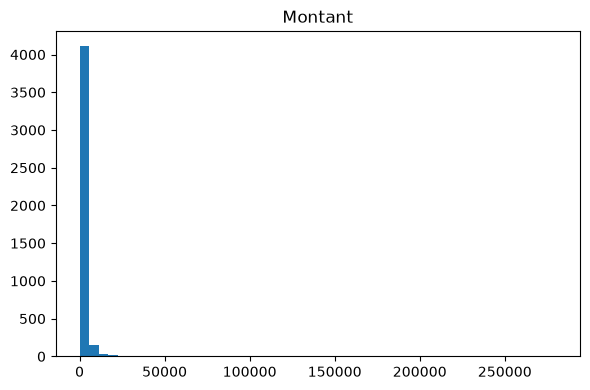

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

In [24]:
rfm['Recence'] = np.log1p(rfm['Recence'])
rfm['Frequence'] = np.log1p(rfm['Frequence'])
rfm['Montant'] = np.log1p(rfm['Montant'])

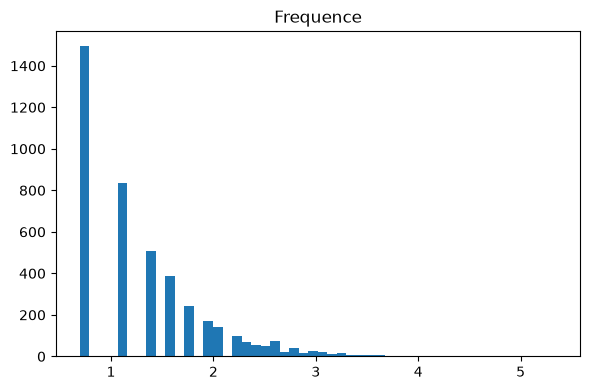

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

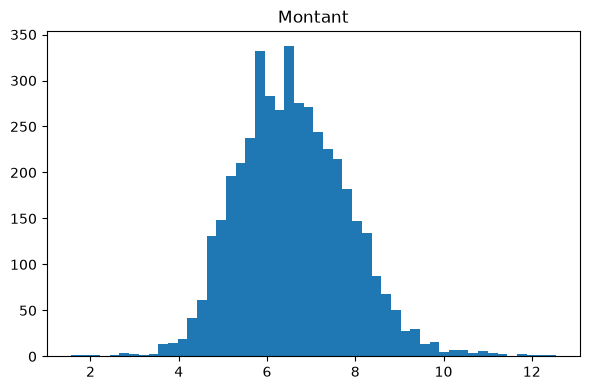

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

### Standarisation

In [27]:
features = ['Recence', 'Frequence', 'Montant']
X = rfm[features]
scaler = StandardScaler()
rfmScaled=scaler.fit_transform(X)
display(rfmScaled)
type(rfmScaled)

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

numpy.ndarray

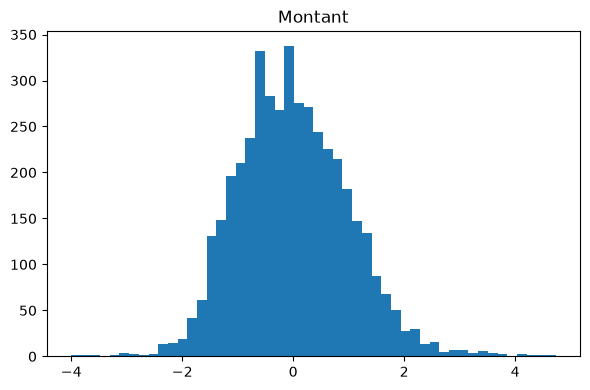

In [28]:
features = ['Recence', 'Frequence', 'Montant']
rfm_scaled = pd.DataFrame(rfmScaled, columns=features, index=rfm['CustomerID'])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

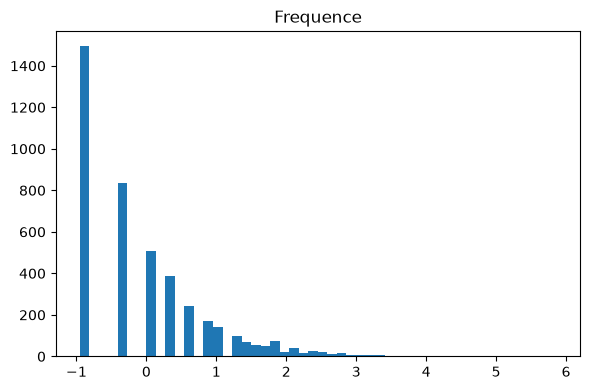

In [29]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

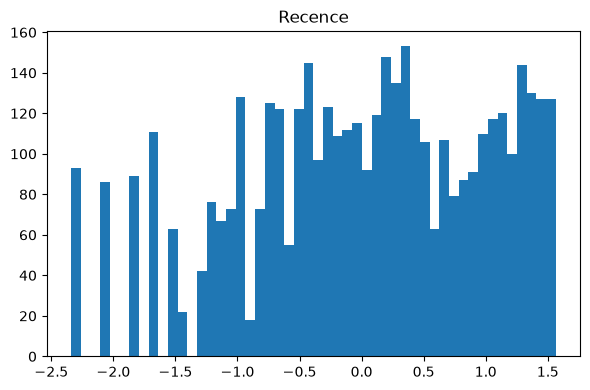

In [30]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Recence'], bins=50)
ax.set_title('Recence')
plt.tight_layout()
plt.show()

### Segmentation avec K-Means

In [31]:
inertias = []


for k in range(1, 20):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    
    kmeans.fit(rfmScaled)
    inertias.append(kmeans.inertia_)
    predicted_labels = kmeans.fit_predict(rfmScaled)
 

In [32]:
print(inertias)

[13014.000000000004, 6481.225323423515, 4867.846645267559, 3938.509953601322, 3295.97632879243, 2855.01124700141, 2548.9143244239403, 2336.7775084644077, 2155.6481927332134, 1999.903269751348, 1872.8327992347972, 1765.27167390351, 1673.3992653928954, 1590.2596801948748, 1513.3979078297334, 1455.8424362999715, 1396.769129019068, 1348.7010949977691, 1300.1470585199995]


## Elbow Method

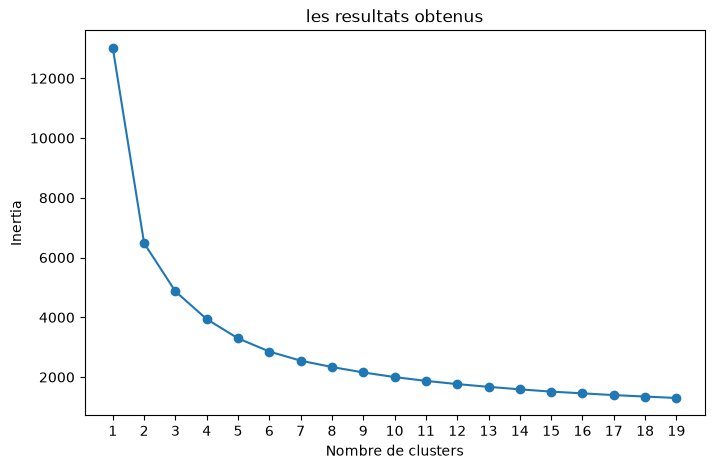

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 20), inertias, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("les resultats obtenus")
plt.xticks(range(1, 20))
plt.show()

In [34]:
Estimation =range(2,8)

###  coefficient de Silhouette 

In [35]:
silhouette_scores = []

for k in Estimation:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_labels = km.fit_predict(rfmScaled)
    silhouette_val = silhouette_score(rfmScaled, predicted_labels)
    silhouette_scores.append(silhouette_val)
    print(f"pour ce k:{k} silhouette_score:{silhouette_val}")
print(km.labels_)


pour ce k:2 silhouette_score:0.43294018131896606
pour ce k:3 silhouette_score:0.33650963406696927
pour ce k:4 silhouette_score:0.3371343622222519
pour ce k:5 silhouette_score:0.31609724178691406
pour ce k:6 silhouette_score:0.31332900440932415
pour ce k:7 silhouette_score:0.3099750749146704
[6 1 6 ... 4 1 6]


C:\Users\Youcode\AppData\Local\Temp\ipykernel_4424\1683976043.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


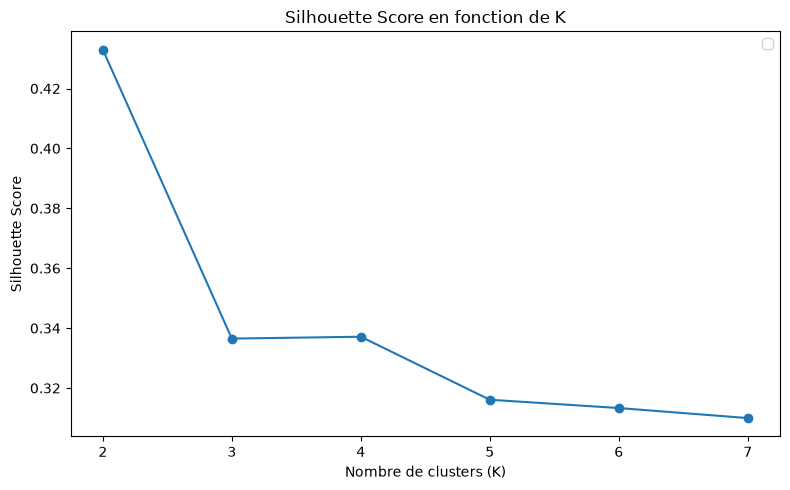

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(Estimation), silhouette_scores, marker='o')
ax.set_xlabel('Nombre de clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score en fonction de K')

ax.legend()
plt.tight_layout()
plt.show()

### Le K ayant le meilleur coefficient de silhouette (0.43) est K=2

In [37]:
k=2
km = KMeans(n_clusters=2,random_state=42,n_init=10)

km.fit(rfmScaled)

predicted_labels = km.fit_predict(rfmScaled)
silhouette_val=silhouette_score(rfmScaled,predicted_labels)
print(f"pour ce 2: silhouette_score:{silhouette_val}")
    
print(km.labels_)

pour ce 2: silhouette_score:0.43294018131896606
[1 1 1 ... 0 1 1]


### la contrainte metier : k=3

### K=2 vs K=3
Le Silhouette Score indique que K=2 donne la meilleure separation statistique entre
les clients. Mais l'entreprise a besoin de 3 segments pour adapter ses actions
marketing (clients fidles, intermédiaires, inactifs)
On garde donc K=3, un
compromis entre ce que dit l'algorithme et ce dont le métier a besoin

K=3 est retenu non pas pour des raisons statistiques (le Silhouette Score préfère K=2)
mais parce que le metier a besoin de 3 segments distincts pour cibler ses actions marketing

## K means avec K-3

In [38]:
Km=KMeans(n_clusters=3,random_state=42)
Km.fit(rfmScaled)
Km.labels_

array([0, 1, 0, ..., 0, 1, 0], shape=(4338,), dtype=int32)

## Ajouter Clusters au tableau

In [39]:
rfm_scaled["Cluster"]= Km.labels_
print(rfm_scaled)
print(f"on a {rfm_scaled['Cluster'].unique().sum() } clusters")
print(rfm_scaled)

             Recence  Frequence   Montant  Cluster
CustomerID                                        
12346.0     1.461993  -0.955214  3.706225        0
12347.0    -2.038734   1.074425  1.411843        1
12348.0     0.373104   0.386304  0.716489        0
12349.0    -0.623086  -0.955214  0.698739        0
12350.0     1.424558  -0.955214 -0.618962        2
...              ...        ...       ...      ...
18280.0     1.343533  -0.955214 -1.106875        2
18281.0     1.024749  -0.955214 -1.740933        2
18282.0    -1.218940  -0.361583 -1.118121        0
18283.0    -1.657552   2.178004  0.838297        1
18287.0    -0.034732   0.059605  0.734002        0

[4338 rows x 4 columns]
on a 3 clusters
             Recence  Frequence   Montant  Cluster
CustomerID                                        
12346.0     1.461993  -0.955214  3.706225        0
12347.0    -2.038734   1.074425  1.411843        1
12348.0     0.373104   0.386304  0.716489        0
12349.0    -0.623086  -0.955214  0.698739

### analyser les caracteistiques des 3 clusters

In [40]:
RFM=np.expm1(
    scaler.inverse_transform(rfm_scaled[['Recence', 'Frequence', 'Montant']]))

RFM= pd.DataFrame(RFM,
                  columns=['Recence', 'Frequence', 'Montant'],
                  index=rfm_scaled.index
                  )
RFM['Cluster']=rfm_scaled['Cluster']
profil_clusters=RFM.groupby('Cluster').agg(
    Nombre_Clients=('Recence', 'count'),
    Recence_Moyenne=('Recence','mean'),
    Frequence_moyenne=('Frequence', 'mean'),
    Montant_moyen=('Montant', 'mean'),
    Montant_total=('Montant', 'sum')
)

print(profil_clusters)

         Nombre_Clients  Recence_Moyenne  Frequence_moyenne  Montant_moyen  \
Cluster                                                                      
0                  1696        44.463443           3.368514    1257.688940   
1                   776        17.070876          13.274485    7865.636662   
2                  1866       167.613076           1.349411     361.539877   

         Montant_total  
Cluster                 
0          2133040.443  
1          6103734.050  
2           674633.411  


### Visualisation des segments avec PCA

In [41]:
features = ['Recence', 'Frequence', 'Montant']

pca = PCA(n_components=2)
principalCom = pca.fit_transform(rfm_scaled[features])


prin_DF = pd.DataFrame(data=principalCom, columns=['Pca1', 'pca2'])


In [42]:
prin_DF['Cluster'] = rfm_scaled['Cluster'].values
prin_DF.head()

,Pca1,pca2,Cluster
0,0.872658,2.686758,0
1,2.550260,-0.804427,1
2,0.475142,0.746121,0
3,0.145832,-0.460480,0
4,-1.688990,0.676555,2


### scattter plot pour pca

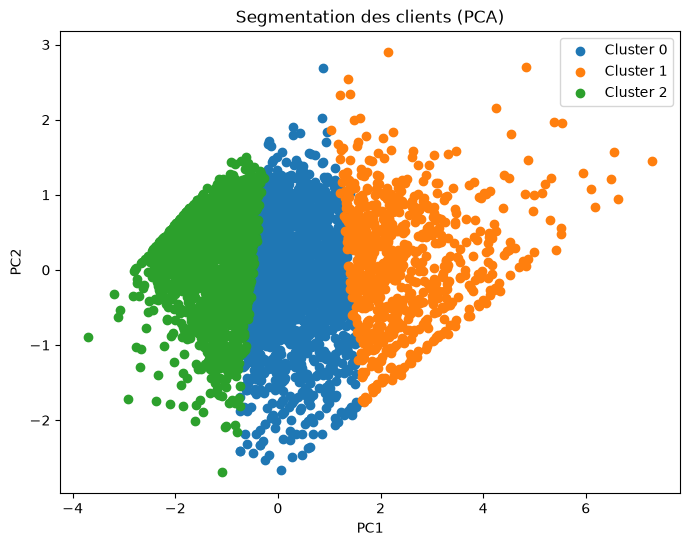

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

for cluster in range(3):
    subset = prin_DF[prin_DF['Cluster'] == cluster]
    ax.scatter(subset['Pca1'], subset['pca2'], label=f'Cluster {cluster}')

ax.set(xlabel='PC1', ylabel='PC2', title='Segmentation des clients (PCA)')
ax.legend()
plt.show()

pca reduire les donnes en 2 dimensions,, et ausii

### trouver les Centroids

In [44]:
centroids_original=np.expm1(scaler.inverse_transform(Km.cluster_centers_))

centroids_df= pd.DataFrame(centroids_original,
                           columns=['Recence', 'Frequence', 'Montant'])

print(centroids_df)


      Recence  Frequence      Montant
0   28.729910   3.091777   952.899969
1    9.216028  10.611609  4240.636865
2  128.104287   1.281118   273.314944


### DBSCAN

In [45]:
features=['Recence', 'Frequence', 'Montant']
clustering= rfm_scaled[features]

model = DBSCAN(min_samples=6,eps=0.4)
Labels=model.fit_predict(clustering)
print(set(Labels)  )


{np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


DBSCAN donne moi 7 clusters 

In [46]:
n_clusters = len(set(Labels)) - (1 if -1 in Labels else 0)
n_noise = list(Labels).count(-1)

print(f"Nombre de clusters : {n_clusters}")
print(f"Nombre de points outliers : {n_noise} ")

pca = PCA(n_components=2)
principalCom = pca.fit_transform(clustering)

dbscan_df = pd.DataFrame(data=principalCom, columns=['Pca1', 'pca2'])
dbscan_df['Cluster'] = Labels


Nombre de clusters : 3
Nombre de points outliers : 122 


### Visualisation de DBSCAN

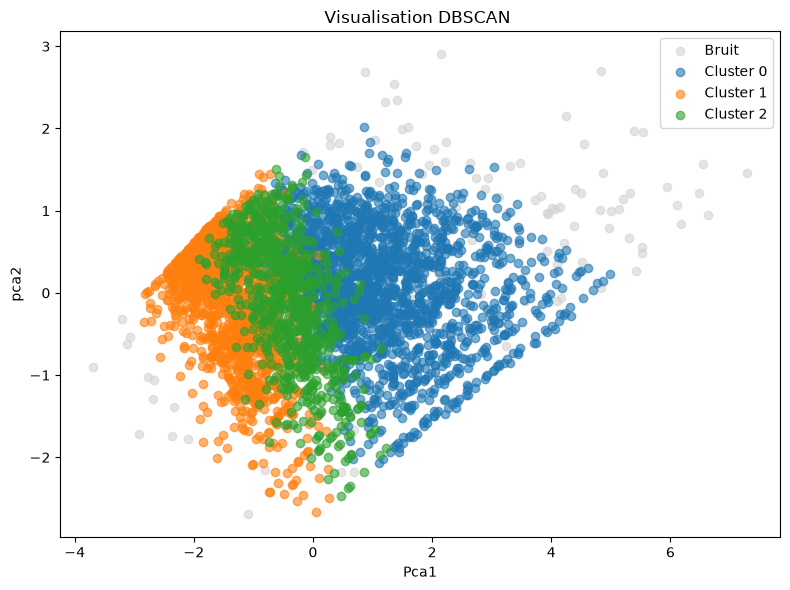

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
for cluster in sorted(dbscan_df['Cluster'].unique()):
    subset = dbscan_df[dbscan_df['Cluster'] == cluster]
    label = 'Bruit' if cluster == -1 else f'Cluster {cluster}'
    color = 'lightgray' if cluster == -1 else None
    ax.scatter(subset['Pca1'], subset['pca2'], label=label, alpha=0.6, color=color)

ax.set_xlabel('Pca1')
ax.set_ylabel('pca2')
ax.set_title('Visualisation DBSCAN ')
ax.legend()
plt.tight_layout()
plt.show()

### Random Forest

In [48]:
y=rfm_scaled["Cluster"]
x = rfm_scaled[['Recence', 'Frequence', 'Montant']]
X_train, X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
rfC= RandomForestClassifier(random_state=42)
rfC.fit(X_train,Y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Evaluation  du modele Rnadom forest 


In [49]:
y_pred = rfC.predict(X_test)

cm = confusion_matrix(Y_test, y_pred)

print("Confusion Matrix")

print("Rows    = Actual")
print("Columns = Predicted")
print()
print(cm)

Confusion Matrix
Rows    = Actual
Columns = Predicted

[[329   3   7]
 [ 11 144   0]
 [  2   0 372]]


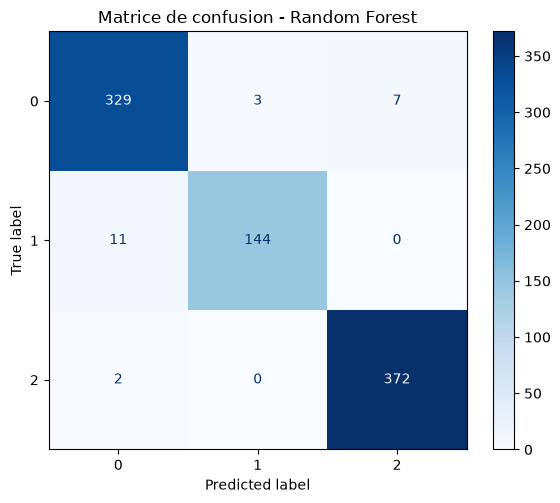

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion - Random Forest')
plt.tight_layout()
plt.show()

In [51]:
cv_scores = cross_val_score(rfC, X_train, Y_train, cv=5, scoring='accuracy')

print("Scores par fold :", cv_scores)
print("Accuracy moyenne :", cv_scores.mean())

Scores par fold : [0.98414986 0.97550432 0.98270893 0.97982709 0.98414986]
Accuracy moyenne : 0.9812680115273775


## Precision + Recall + F1

In [52]:
precision_cv = cross_val_score(rfC, X_train, Y_train, cv=5, scoring='precision_weighted')
recall_cv = cross_val_score(rfC, X_train, Y_train, cv=5, scoring='recall_weighted')
f1_cv = cross_val_score(rfC, X_train, Y_train, cv=5, scoring='f1_weighted')

print("Precision (CV) :", precision_cv.mean())
print("Recall (CV)    :", recall_cv.mean())
print("F1-score (CV)  :", f1_cv.mean())

Precision (CV) : 0.9813806334319777
Recall (CV)    : 0.9812680115273775
F1-score (CV)  : 0.981269655838904


### KNN

In [53]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,Y_train)

pred = knn.predict(X_test)

## Evaluation et predections

In [54]:
print(confusion_matrix(Y_test,pred))
print(classification_report(Y_test,pred))

[[333   5   1]
 [  6 149   0]
 [  2   0 372]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       339
           1       0.97      0.96      0.96       155
           2       1.00      0.99      1.00       374

    accuracy                           0.98       868
   macro avg       0.98      0.98      0.98       868
weighted avg       0.98      0.98      0.98       868



## trouver le meilleieur K pour KNN

In [55]:
error_rate=[]

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,Y_train)
    pred_i=knn.predict(X_test)
    error_rate.append(np.mean(pred_i != Y_test))

Text(0, 0.5, 'error rate')

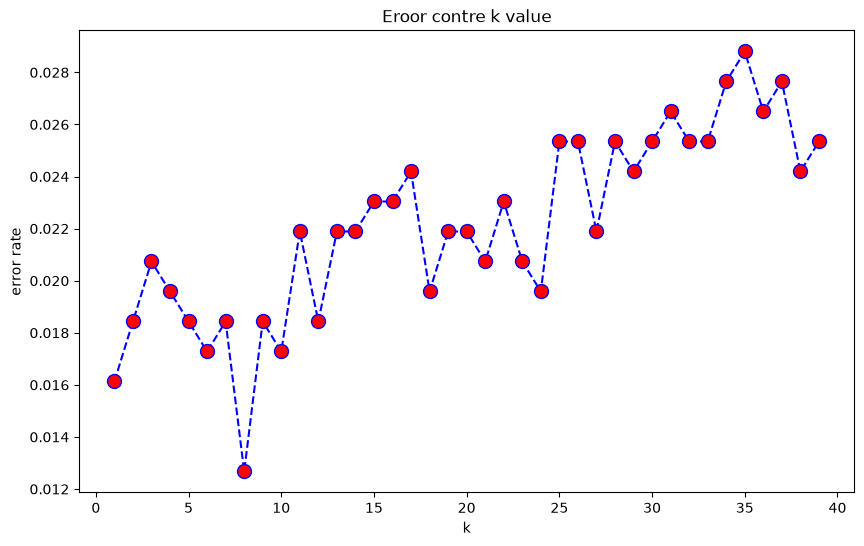

In [56]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)

plt.title("Eroor contre k value")
plt.xlabel('k')
plt.ylabel("error rate")

## le Meil K =8

In [57]:
best_Knn=KNeighborsClassifier(n_neighbors=8)

knn.fit(X_train,Y_train)

p=knn.predict(X_test)
print(confusion_matrix(Y_test,p))
print(classification_report(Y_test,pred))


[[328   0  11]
 [  8 147   0]
 [  3   0 371]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       339
           1       0.97      0.96      0.96       155
           2       1.00      0.99      1.00       374

    accuracy                           0.98       868
   macro avg       0.98      0.98      0.98       868
weighted avg       0.98      0.98      0.98       868



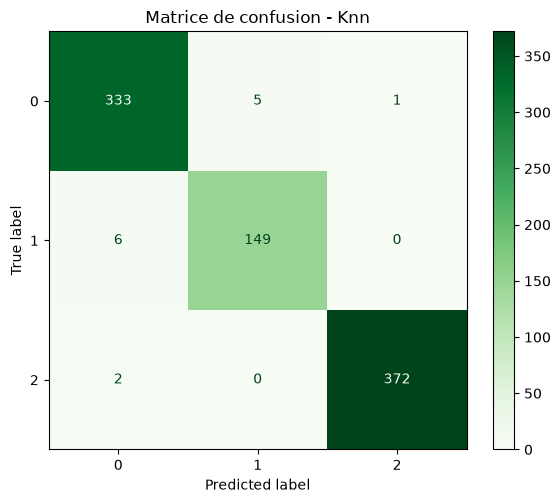

In [62]:

M_BestK=confusion_matrix(Y_test,pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=M_BestK, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Greens')
ax.set_title('Matrice de confusion - Knn')
plt.tight_layout()
plt.show()

## Logistic Regression

In [64]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, Y_train)

y_pred_log = log_reg.predict(X_test)

print("Accuracy :", accuracy_score(Y_test, y_pred_log))
print(classification_report(Y_test, y_pred_log))
print(confusion_matrix(Y_test, y_pred_log))

Accuracy : 0.9953917050691244
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       339
           1       1.00      0.99      0.99       155
           2       0.99      1.00      1.00       374

    accuracy                           1.00       868
   macro avg       1.00      0.99      0.99       868
weighted avg       1.00      1.00      1.00       868

[[337   0   2]
 [  2 153   0]
 [  0   0 374]]


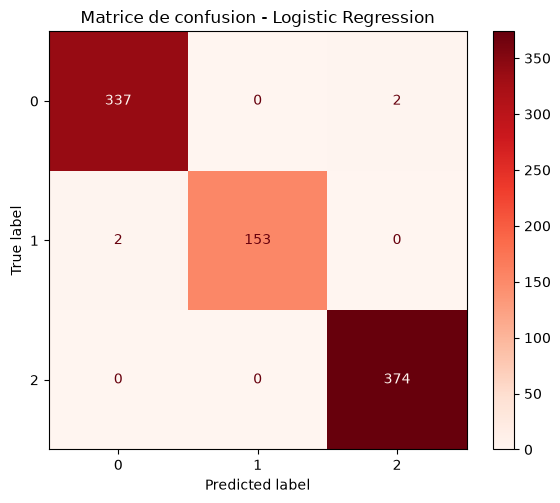

In [69]:
Matrix=confusion_matrix(Y_test,y_pred_log)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=Matrix, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Reds')
ax.set_title('Matrice de confusion - Logistic Regression')
plt.tight_layout()
plt.show()

## Partie 9 — Importance des variables (Random Forest)

On mesure ici quelles variables RFM (Récence, Fréquence, Montant) pèsent le plus dans les décisions
de la forêt aléatoire. Les valeurs proviennent de `rfC.feature_importances_`, c'est-à-dire du modèle
déjà entraîné dans les cellules précédentes (on ne modifie rien).


In [61]:
# Importance des variables de la forêt aléatoire déjà entraînée.
# L'ordre des importances correspond aux colonnes de x : ['Recence', 'Frequence', 'Montant'].
importances = rfC.feature_importances_

importance_df = pd.DataFrame({
    'Variable': ['Recence', 'Frequence', 'Montant'],
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(importance_df)

# Même tableau en pourcentage pour une lecture plus facile.
importance_df['Importance (%)'] = (importance_df['Importance'] * 100).round(2)
display(importance_df[['Variable', 'Importance (%)']])


,Variable,Importance
0,Frequence,0.345975
1,Montant,0.330115
2,Recence,0.323910


,Variable,Importance (%)
0,Frequence,34.60
1,Montant,33.01
2,Recence,32.39


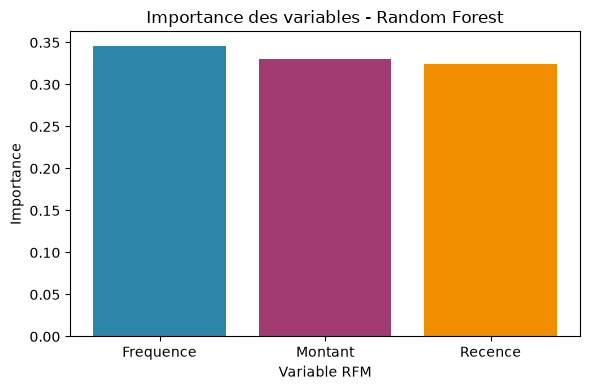

In [62]:
# Diagramme en barres de l'importance des variables.
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(importance_df['Variable'], importance_df['Importance'],
       color=['#2E86AB', '#A23B72', '#F18F01'])
ax.set_title("Importance des variables - Random Forest")
ax.set_ylabel("Importance")
ax.set_xlabel("Variable RFM")
plt.tight_layout()
plt.show()


### Interprétation

D'après les valeurs obtenues, les trois variables ont une importance très proche :
**Fréquence** (environ 34,6 %), **Montant** (environ 33,0 %) et **Récence** (environ 32,4 %).

C'est donc la **fréquence d'achat** qui est légèrement la plus discriminante : c'est le premier
critère qui permet de séparer les clients très actifs (cluster 1) des clients occasionnels (cluster 2).
Le **montant dépensé** arrive juste après, ce qui confirme que la valeur monétaire reste un signal
important pour identifier les clients à forte valeur. La **récence** ferme la marche mais reste
presque au même niveau : elle complète bien la fréquence pour repérer les clients inactifs.

Au final, aucune variable n'écrase les autres : les trois indicateurs RFM sont **complémentaires**
et contribuent presque à parts égales à la décision du modèle. Ce résultat est cohérent avec le fait
que la segmentation RFM repose sur les trois dimensions à la fois.


## Partie 10 — Prédiction d'un nouveau client

Un utilisateur saisit des valeurs RFM **brutes** (jours, nombre de commandes, euros).
Pour éviter toute erreur de prétraitement, on construit une **pipeline scikit-learn** qui applique
exactement la même transformation que lors de l'entraînement : `log1p` puis `StandardScaler`,
avant le classifieur. Ainsi, les valeurs brutes sont transformées automatiquement et on ne
risque jamais d'appliquer `log1p` deux fois.


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Fonction utilitaire : construit une pipeline identique pour tous les classifieurs.
# La pipeline part de valeurs BRUTES et applique log1p puis StandardScaler.
def creer_pipeline(classifieur):
    return Pipeline([
        ('log', FunctionTransformer(np.log1p)),   # valeurs brutes -> log1p
        ('scaler', StandardScaler()),             # standardisation comme à l'entraînement
        ('clf', classifieur),                     # le classifieur (RF, LogReg, KNN...)
    ])

# RFM contient les vraies valeurs (obtenues par expm1 + inverse_transform dans les cellules précédentes).
X_brut = RFM[['Recence', 'Frequence', 'Montant']]
y_brut = RFM['Cluster']

# Même découpage que les modèles existants : mêmes random_state et stratify.
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_brut, y_brut, test_size=0.2, random_state=42, stratify=y_brut
)

# Pipeline Random Forest entraînée sur les valeurs BRUTES (réutilisée dans la Partie 11).
pipeline_rf = creer_pipeline(RandomForestClassifier(random_state=42))
pipeline_rf.fit(X_train_raw, Y_train_raw)

print("Pipeline Random Forest entraînée sur les valeurs RFM brutes : OK")


Pipeline Random Forest entraînée sur les valeurs RFM brutes : OK


In [64]:
# Exemple de nouveau client (valeurs BRUTES : jours, nombre de commandes, euros).
nouveau_client = pd.DataFrame({
    'Recence': [15],      # 15 jours depuis le dernier achat -> client récent
    'Frequence': [12],    # 12 commandes
    'Montant': [4800.0],  # 4800 euros dépensés au total
})

# Prédiction du cluster par la pipeline (les valeurs brutes sont transformées automatiquement).
cluster_predit = int(pipeline_rf.predict(nouveau_client)[0])
probabilites = pipeline_rf.predict_proba(nouveau_client)[0]
confiance = float(probabilites.max())

# Correspondance cluster -> nom du segment (vérifiée sur le profil réel des clusters).
noms_segments = {
    0: "Clients intermédiaires",
    1: "Clients à forte valeur",
    2: "Clients inactifs / occasionnels",
}

print("Informations RFM du nouveau client :")
display(nouveau_client)
print(f"Cluster prédit    : {cluster_predit}")
print(f"Segment du client : {noms_segments.get(cluster_predit, 'Segment inconnu')}")
print(f"Confiance         : {confiance * 100:.1f} %")


Informations RFM du nouveau client :


,Recence,Frequence,Montant
0,15,12,4800.0


Cluster prédit    : 1
Segment du client : Clients à forte valeur
Confiance         : 100.0 %


## Partie 11 — Sauvegarde des modèles

On entraîne les trois classifieurs (Random Forest, Régression logistique, KNN) sous forme de
pipelines partant de valeurs brutes, puis on les sauvegarde avec `joblib` dans le dossier `models/`.
On enregistre aussi leurs performances (accuracy et F1 pondéré) dans `models/metrics.json`.


In [65]:
import joblib
import json
import os
from sklearn.metrics import f1_score

# Dossier de sauvegarde (créé s'il n'existe pas encore).
os.makedirs('models', exist_ok=True)

# On réutilise la pipeline Random Forest de la Partie 10 et on construit les deux autres.
pipelines = {
    'random_forest': pipeline_rf,
    'logistic_regression': creer_pipeline(LogisticRegression(random_state=42, max_iter=1000)),
    'knn': creer_pipeline(KNeighborsClassifier(n_neighbors=8)),
}

# Entraînement des pipelines qui ne le sont pas encore (la RF est déjà entraînée).
pipelines['logistic_regression'].fit(X_train_raw, Y_train_raw)
pipelines['knn'].fit(X_train_raw, Y_train_raw)

# Évaluation sur le même jeu de test + sauvegarde de chaque modèle.
metriques = {}
for nom, modele in pipelines.items():
    prediction = modele.predict(X_test_raw)
    metriques[nom] = {
        'accuracy': float(accuracy_score(Y_test_raw, prediction)),
        'f1_weighted': float(f1_score(Y_test_raw, prediction, average='weighted')),
    }
    joblib.dump(modele, f'models/{nom}.joblib')
    print(f"{nom:20s} -> accuracy = {metriques[nom]['accuracy']:.4f} | F1 pondéré = {metriques[nom]['f1_weighted']:.4f}")

# Sauvegarde des métriques dans un fichier JSON (utilisé par l'application Streamlit).
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metriques, f, indent=4, ensure_ascii=False)

print("\nModèles et métriques sauvegardés dans le dossier 'models/'.")


random_forest        -> accuracy = 0.9735 | F1 pondéré = 0.9734
logistic_regression  -> accuracy = 0.9954 | F1 pondéré = 0.9954
knn                  -> accuracy = 0.9885 | F1 pondéré = 0.9884

Modèles et métriques sauvegardés dans le dossier 'models/'.


In [66]:
# Rechargement du modèle sauvegardé et vérification qu'il prédit la même chose.
rf_recharge = joblib.load('models/random_forest.joblib')

prediction_en_memoire = int(pipeline_rf.predict(nouveau_client)[0])
prediction_rechargee = int(rf_recharge.predict(nouveau_client)[0])

print(f"Prédiction du modèle en mémoire : {prediction_en_memoire}")
print(f"Prédiction du modèle rechargé   : {prediction_rechargee}")
assert prediction_en_memoire == prediction_rechargee, "Les prédictions diffèrent !"
print("Les deux prédictions sont identiques : la sauvegarde est correcte.")


Prédiction du modèle en mémoire : 1
Prédiction du modèle rechargé   : 1
Les deux prédictions sont identiques : la sauvegarde est correcte.


## Partie 12 — Application Streamlit

L'application interactive se trouve dans le fichier `app/streamlit_app.py`.
Elle charge les modèles sauvegardés, propose trois champs de saisie RFM et retourne le segment prédit.

Pour la lancer depuis la racine du projet :

```bash
streamlit run app/streamlit_app.py
```
